<a href="https://colab.research.google.com/github/ismael-almazan/PNL/blob/main/Proyecto_Final_PNL.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<div align="center">

#  **PROYECTO FINAL**  
## *Predicción de Síntomas Médicos*  
### Procesamiento del Lenguaje Natural  

<br>

---

<br>

###  **Ismael Almazán Luna**  
**Matrícula:** 263177  

<br>

###  **Docente**  
**Rogelio Florencia Juárez**  

<br>

###  **Fecha**  
**22 de mayo de 2026**  

<br>

---

<br>

###  **Universidad Autónoma de Ciudad Juárez**  
###  *Instituto de Ingeniería y Tecnología*  
###  *Maestría en Inteligencia Artificial y Analítica de Datos*  

</div>

En este proyecto desarrollarán un sistema para la predicción de síntomas médicos a partir de datos textuales recogidos de registros o transcripciones médicas. El objetivo es aplicar técnicas de PLN para preprocesar, representar, modelar y evaluar el texto con foco en aplicaciones de salud.

El dataset contiene ejemplos de diferentes síntomas médicos descritos en formato textual con el objetivo de construir modelos que puedan identificar el síntoma presente en una entrada dada. Cada muestra pertenece a una de varias clases que representan síntomas o condiciones comunes reportadas por pacientes.


## Librerias requeridas y carga de datos

In [1]:
# LIBRERIAS
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import spacy
import numpy as np
from wordcloud import WordCloud
from collections import Counter
from nltk.corpus import stopwords
import nltk
import torch
import numpy as np
from transformers import AutoTokenizer, AutoModel
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, clasification_report
import pandas as pd



In [2]:
# CARGA DE DATASET CON PANDAS

# Conectar con Google Drive para cargar el Dataset
from google.colab import drive
drive.mount('/content/drive')

# Cargar con Pandas en un Dataframe
df = pd.read_csv('/content/drive/MyDrive/ClassFiles/PNL/Dataset.csv', encoding='utf-8')
# Comprobar la carga del Dataset
df.head(6)

Mounted at /content/drive


,phrase,prompt
0,When I remember her I feel down,Emotional pain
1,When I carry heavy things I feel like breaking...,Hair falling out
2,there is too much pain when i move my arm,Heart hurts
3,My son had his lip pierced and it is swollen a...,Infected wound
4,My muscles in my lower back are aching,Infected wound
5,i have muscle pain that my back\nI Have Muscle...,Foot ache


# Análisis exploratorio (EDA)

## Inspeccion del Dataset

In [3]:
nlp = spacy.load("en_core_web_sm")

# Cantidad de registros
print ("Cantidad de registros:", df.shape)

# Cantidad de registros duplicados
print("Cantidad de registros duplicados:", df.duplicated().sum())

# Numero de clases
print("cantidad de clases:", df['prompt'].nunique())

# Numero promedio de palabras o tokens
print(f"Promedio de palabras de los textos: {df['phrase'].dropna().apply(lambda x: len(nlp(x))).mean():.2f}")

# Numero maxio de palabras o tokens
print(f"Maximo de palabras de los textos: {df['phrase'].dropna().apply(lambda x: len(nlp(x))).max():.2f}")

# Numero minimo de palabras o tokens
print(f"Minimo de palabras de los textos: {df['phrase'].dropna().apply(lambda x: len(nlp(x))).min():.2f}")


Cantidad de registros: (6661, 2)
Cantidad de registros duplicados: 5954
cantidad de clases: 25
Promedio de palabras de los textos: 11.49
Maximo de palabras de los textos: 36.00
Minimo de palabras de los textos: 3.00


## Distribucion de las clases

distribucion de clases 
 prompt
Acne                  328
Shoulder pain         320
Joint pain            318
Infected wound        306
Knee pain             305
Cough                 293
Feeling dizzy         283
Muscle pain           282
Heart hurts           273
Ear ache              270
Hair falling out      264
Feeling cold          263
Head ache             263
Skin issue            262
Stomach ache          261
Back pain             259
Neck pain             251
Internal pain         248
Blurry vision         246
Body feels weak       241
Hard to breath        233
Emotional pain        231
Injury from sports    230
Foot ache             223
Open wound            208
Name: count, dtype: int64


/tmp/ipykernel_3951/1957482233.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='prompt', data=df, palette='mako')


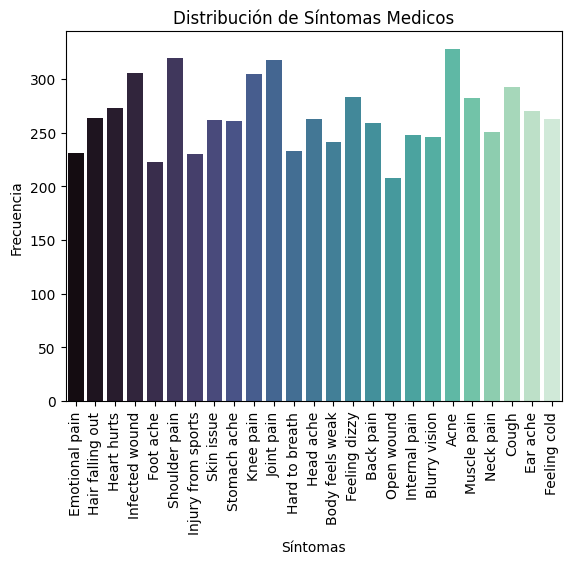

In [4]:
# Frecuencia de las clases
print("distribucion de clases \n", df['prompt'].value_counts())

# Grafica de barras de las clases
sns.countplot(x='prompt', data=df, palette='mako')
plt.xlabel('Síntomas')
plt.ylabel('Frecuencia')
plt.title('Distribución de Síntomas Medicos')
plt.xticks(rotation=90)
plt.show()

## Analisis de vocabulario

Cantidad de palabras únicas: 1363




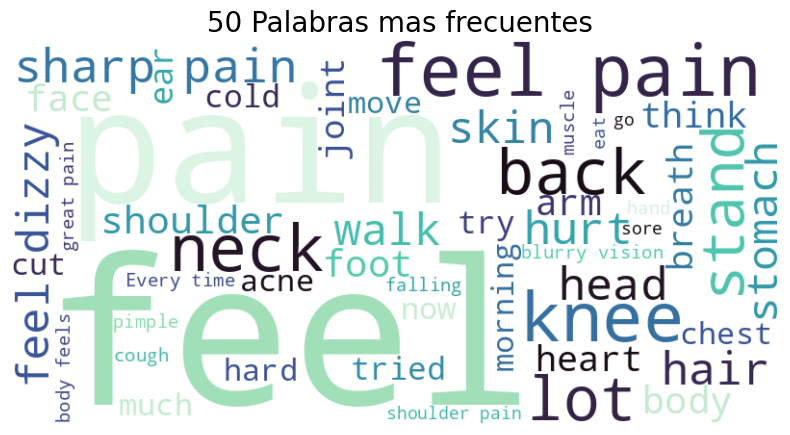

In [5]:
# Cantidad de palabras unicas
print("Cantidad de palabras únicas:", len(set(df['phrase'].dropna().str.lower().str.cat(sep=' ').split())))
print("\n")

# Unir todo el texto
texto_completo = " ".join(df["phrase"].dropna().astype(str))

# Nube de palabras
wc = WordCloud(
    background_color="white",
    max_words=50,
    width=800,
    height=400,
    colormap="mako",
).generate(texto_completo)

# 3. Graficamos el resultado
plt.figure(figsize=(10, 5))
plt.imshow(wc, interpolation="bilinear")
plt.title(" 50 Palabras mas frecuentes", fontsize=20)
plt.axis("off")  # Oculta los ejes del gráfico
plt.show()

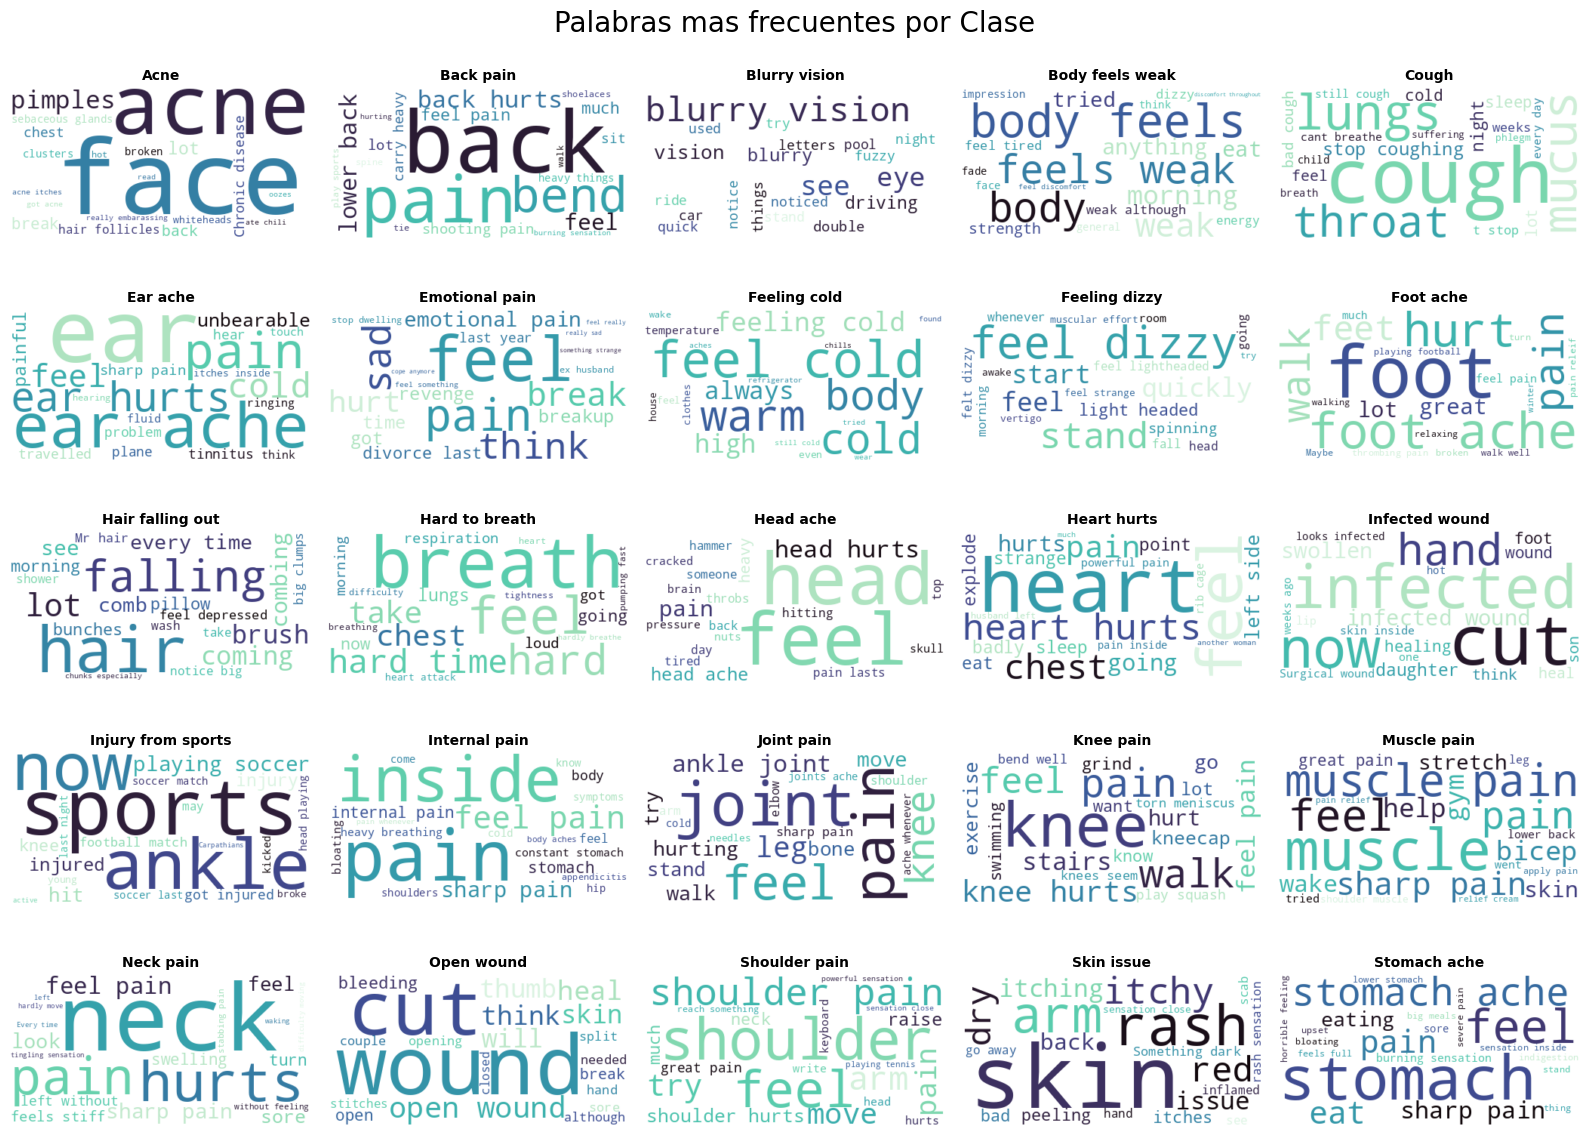

In [6]:

# Funcion para graficar nubes por clase con las 20 palabras mas frecuentes
def graficar_nube(texto, ax, titulo):
    wc = WordCloud(background_color="white", max_words=20, colormap="mako").generate(texto)
    ax.imshow(wc, interpolation="bilinear")
    ax.set_title(titulo, fontsize=10, fontweight="bold")
    ax.axis("off")

# Configuracion de subplot
fig, axes = plt.subplots(5, 5, figsize=(16, 12))
axes_planos = axes.flatten()

# Agrupar por clases
for i, (clase, sub_df) in enumerate(df.groupby('prompt')):

    # Unir texto
    texto_clase = " ".join(sub_df['phrase'].dropna().astype(str))

    if texto_clase.strip():
        graficar_nube(texto_clase, axes_planos[i], clase)

plt.suptitle("Palabras mas frecuentes por Clase", fontsize=20)
plt.tight_layout()
plt.show()

# Preprocesamiento y normalización

## Analisis de duplicados

In [7]:
# Cantidad de registros
print ("Cantidad de registros df original:", df.shape)

# Cantidad de registros duplicados
print("Cantidad de registros duplicados:", df.duplicated().sum())

# Generar un df extra que no contenga duplicados para comparar modelos
df2 = df.drop_duplicates()
print("Cantidad de registros df sin duplicados", df2.shape)

Cantidad de registros df original: (6661, 2)
Cantidad de registros duplicados: 5954
Cantidad de registros df sin duplicados (707, 2)


distribucion de clases sin duplicados 
 prompt
Shoulder pain         35
Infected wound        34
Joint pain            34
Acne                  34
Knee pain             32
Cough                 31
Heart hurts           31
Skin issue            29
Muscle pain           29
Hair falling out      28
Ear ache              28
Foot ache             27
Injury from sports    27
Feeling cold          27
Stomach ache          27
Head ache             27
Back pain             27
Internal pain         26
Blurry vision         26
Body feels weak       26
Feeling dizzy         26
Neck pain             25
Hard to breath        25
Emotional pain        24
Open wound            22
Name: count, dtype: int64


/tmp/ipykernel_3951/1036097688.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='prompt', data=df2, palette='mako')


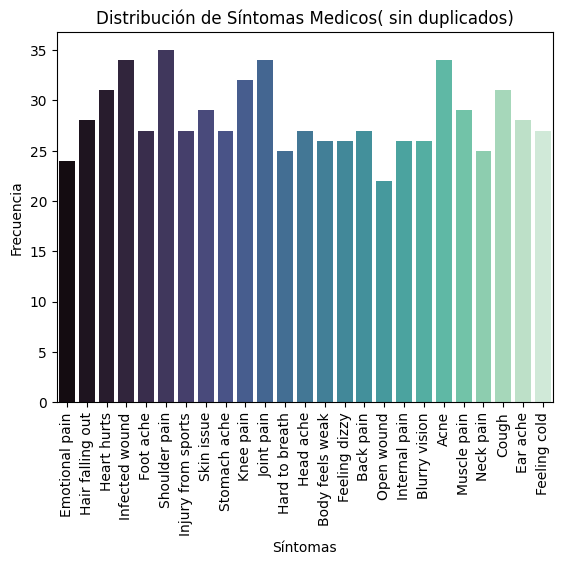

In [8]:
# Frecuencia de las clases sin duplicados
print("distribucion de clases sin duplicados \n", df2['prompt'].value_counts())

# Grafica de barras de las clases sin duplicados
sns.countplot(x='prompt', data=df2, palette='mako')
plt.xlabel('Síntomas')
plt.ylabel('Frecuencia')
plt.title('Distribución de Síntomas Medicos( sin duplicados)')
plt.xticks(rotation=90)
plt.show()

## Normalizacion y preprocesamiento para embeddings

In [9]:
# Copias de los dfs
df_norm = df.copy()
df2_norm = df2.copy()

# Limpieza de espacios en blanco en la columna 'phrase'
df_norm['phrase'] = df_norm['phrase'].str.strip()
df2_norm['phrase'] = df2_norm['phrase'].str.strip()

# Limpieza de caracteres especiales en la columna 'phrase'
df_norm['phrase'] = df_norm['phrase'].str.replace(r"[^a-zA-Z0-9\s.,]", "", regex=True)
df2_norm['phrase'] = df2_norm['phrase'].str.replace(r"[^a-zA-Z0-9\s.,]", "", regex=True)

In [10]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

# Ajustar datasets
all_labels = pd.concat([df_norm['prompt'], df2_norm['prompt']])
le.fit(all_labels)

# Transformar
df_norm['label'] = le.transform(df_norm['prompt'])
df2_norm['label'] = le.transform(df2_norm['prompt'])

# Extraer vectores de etiquetas
y_df_norm = df_norm['label'].values
y_df2_norm = df2_norm['label'].values

df_norm.head(8)

,phrase,prompt,label
0,When I remember her I feel down,Emotional pain,6
1,When I carry heavy things I feel like breaking...,Hair falling out,10
2,there is too much pain when i move my arm,Heart hurts,13
3,My son had his lip pierced and it is swollen a...,Infected wound,14
4,My muscles in my lower back are aching,Infected wound,14
5,i have muscle pain that my back\nI Have Muscle...,Foot ache,9
6,I have muscle pain in my left leg,Shoulder pain,22
7,I have cut my finger because of playing footba...,Injury from sports,15


# Representacion vectorial

In [11]:
# Definir la vectorizacion en una funcion para aplicar al df original y al df sin duplicado
def biobert_vectorize(df_norm, df2_norm, text_column="phrase", batch_size=16, max_length=128):

    MODEL_NAME = "dmis-lab/biobert-base-cased-v1.1"

    # cargar modelo
    tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
    model = AutoModel.from_pretrained(MODEL_NAME)

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)
    model.eval()

    def process(texts):
        embeddings_list = []

        with torch.no_grad():
            for i in range(0, len(texts), batch_size):
                batch = texts[i:i+batch_size]

                inputs = tokenizer(
                    batch,
                    padding=True,
                    truncation=True,
                    max_length=max_length,
                    return_tensors="pt"
                )

                inputs = {k: v.to(device) for k, v in inputs.items()}

                outputs = model(**inputs)

                # CLS embedding
                cls_embeddings = outputs.last_hidden_state[:, 0, :]

                embeddings_list.append(cls_embeddings.cpu().numpy())

        return np.vstack(embeddings_list)

    # extraer textos
    texts_df1 = df_norm[text_column].astype(str).tolist()
    texts_df2 = df2_norm[text_column].astype(str).tolist()

    # vectorizar
    X_df_norm = process(texts_df1)
    X_df2_norm = process(texts_df2)

    return X_df_norm, X_df2_norm

# Aplicar vectorización con BioBERT
X_df_norm, X_df2_norm = biobert_vectorize(df_norm, df2_norm, text_column="phrase")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/313 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/436M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/436M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: dmis-lab/biobert-base-cased-v1.1
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.decoder.weight             | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.decoder.bias               | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


  # Validación cruzada

In [12]:
from sklearn.model_selection import StratifiedKFold
#funciion para estratificart ambos dfs
def stratified_kfold_split(X, y, n_splits=10):

    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)

    folds = []

    for fold, (train_idx, test_idx) in enumerate(skf.split(X, y), 1):

        X_train, X_test = X[train_idx], X[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]

        folds.append({
            "fold": fold,
            "X_train": X_train,
            "X_test": X_test,
            "y_train": y_train,
            "y_test": y_test
        })

        print(f"Fold {fold} | Train: {X_train.shape} | Test: {X_test.shape}")

    return folds

# Dataset 1
folds_df_norm = stratified_kfold_split(X_df_norm, y_df_norm)

print("\n" + "="*50 + "\n")

# Dataset 2
folds_df2_norm = stratified_kfold_split(X_df2_norm, y_df2_norm)

Fold 1 | Train: (5994, 768) | Test: (667, 768)
Fold 2 | Train: (5995, 768) | Test: (666, 768)
Fold 3 | Train: (5995, 768) | Test: (666, 768)
Fold 4 | Train: (5995, 768) | Test: (666, 768)
Fold 5 | Train: (5995, 768) | Test: (666, 768)
Fold 6 | Train: (5995, 768) | Test: (666, 768)
Fold 7 | Train: (5995, 768) | Test: (666, 768)
Fold 8 | Train: (5995, 768) | Test: (666, 768)
Fold 9 | Train: (5995, 768) | Test: (666, 768)
Fold 10 | Train: (5995, 768) | Test: (666, 768)


Fold 1 | Train: (636, 768) | Test: (71, 768)
Fold 2 | Train: (636, 768) | Test: (71, 768)
Fold 3 | Train: (636, 768) | Test: (71, 768)
Fold 4 | Train: (636, 768) | Test: (71, 768)
Fold 5 | Train: (636, 768) | Test: (71, 768)
Fold 6 | Train: (636, 768) | Test: (71, 768)
Fold 7 | Train: (636, 768) | Test: (71, 768)
Fold 8 | Train: (637, 768) | Test: (70, 768)
Fold 9 | Train: (637, 768) | Test: (70, 768)
Fold 10 | Train: (637, 768) | Test: (70, 768)


# Entrenamiento de Modelos

In [14]:
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score
import pandas as pd

# Funcion para entrena modelos con ambos datsets
def train_models_fast(X, y):

    models = {
        "Logistic Regression": LogisticRegression(
            C=1, class_weight="balanced", max_iter=1000, n_jobs=-1
        ),
        "SGD Classifier (SVM lineal)": SGDClassifier(
            loss="hinge", alpha=0.001, class_weight="balanced",
            max_iter=200, random_state=42, n_jobs=-1
        ),
        "Random Forest": RandomForestClassifier(
            n_estimators=100, max_depth=10,
            class_weight="balanced", random_state=42, n_jobs=-1
        ),
    }

    results = []

    for name, model in models.items():
        scores = cross_val_score(model, X, y, cv=10, scoring="f1_weighted", n_jobs=-1)
        results.append({
            "Modelo": name,
            "F1 promedio (CV=10)": scores.mean().round(4),
            "Desv. estándar": scores.std().round(4),
        })
        print(f"  {name}: F1={scores.mean():.4f} ± {scores.std():.4f}")

    return pd.DataFrame(results).sort_values(by="F1 promedio (CV=10)", ascending=False)

# Dataset 1
print("Resultados df_norm:")
results_df_norm = train_models_fast(X_df_norm, y_df_norm)
print(results_df_norm)

# Dataset 2
print("Resultados df2_norm:")
results_df2_norm = train_models_fast(X_df2_norm, y_df2_norm)
print(results_df2_norm)

Resultados df_norm:
  Logistic Regression: F1=0.9983 ± 0.0050
  SGD Classifier (SVM lineal): F1=0.9915 ± 0.0096
  Random Forest: F1=0.9982 ± 0.0054
                        Modelo  F1 promedio (CV=10)  Desv. estándar
0          Logistic Regression               0.9983          0.0050
2                Random Forest               0.9982          0.0054
1  SGD Classifier (SVM lineal)               0.9915          0.0096


Resultados df2_norm:
  Logistic Regression: F1=0.6345 ± 0.0547
  SGD Classifier (SVM lineal): F1=0.5144 ± 0.0759
  Random Forest: F1=0.4160 ± 0.0616
                        Modelo  F1 promedio (CV=10)  Desv. estándar
0          Logistic Regression               0.6345          0.0547
1  SGD Classifier (SVM lineal)               0.5144          0.0759
2                Random Forest               0.4160          0.0616


# Evaluacion de Modelos

In [17]:
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import classification_report, accuracy_score
import pandas as pd

def evaluar_modelos(X, y, nombre_dataset):

    models = {
        "Logistic Regression": LogisticRegression(C=1, class_weight="balanced", max_iter=1000, n_jobs=-1),
        "SGD Classifier (SVM lineal)": SGDClassifier(loss="hinge", alpha=0.001, class_weight="balanced", max_iter=200, random_state=42, n_jobs=-1),
        "Random Forest": RandomForestClassifier(n_estimators=100, max_depth=10, class_weight="balanced", random_state=42, n_jobs=-1),
    }

    skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)


    print(f"Evaluación: {nombre_dataset}")


    for name, model in models.items():

        y_true_all, y_pred_all = [], []

        for train_idx, test_idx in skf.split(X, y):
            model.fit(X[train_idx], y[train_idx])
            y_pred = model.predict(X[test_idx])
            y_true_all.extend(y[test_idx])
            y_pred_all.extend(y_pred)

        print(f"\n--- {name} ---")
        print(f"Accuracy: {accuracy_score(y_true_all, y_pred_all):.4f}")
        print(classification_report(y_true_all, y_pred_all, target_names=le.classes_))

# Dataset 1
evaluar_modelos(X_df_norm, y_df_norm, "df original")

# Dataset 2
evaluar_modelos(X_df2_norm, y_df2_norm, "df sin duplicados")

Evaluación: df original

--- Logistic Regression ---
Accuracy: 0.9983
                    precision    recall  f1-score   support

              Acne       1.00      1.00      1.00       328
         Back pain       1.00      1.00      1.00       259
     Blurry vision       1.00      1.00      1.00       246
   Body feels weak       1.00      1.00      1.00       241
             Cough       1.00      1.00      1.00       293
          Ear ache       1.00      1.00      1.00       270
    Emotional pain       1.00      1.00      1.00       231
      Feeling cold       1.00      1.00      1.00       263
     Feeling dizzy       1.00      1.00      1.00       283
         Foot ache       1.00      0.99      1.00       223
  Hair falling out       1.00      1.00      1.00       264
    Hard to breath       1.00      1.00      1.00       233
         Head ache       1.00      1.00      1.00       263
       Heart hurts       1.00      0.99      1.00       273
    Infected wound       1.00